<img src="../../_images/logos/seaborn.svg" width="200px">

# Seaborn Lesson - Topic 05 - Seaborn Plots: Part 03

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Learn and deliver heatmap, line plot and categorical plot in Seaborn


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 


## Import Packages for Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Seaborn Plots: Part 03

We will cover in this topic the following plots:
* Heatmap
* Line plot
* Categorical plot

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Heatmap

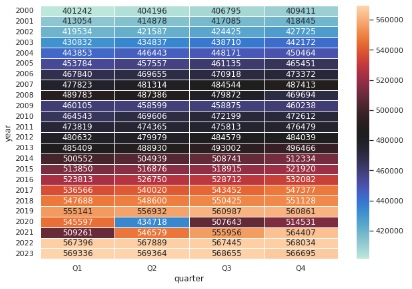

A heatmap represents data in a matrix form as a map or diagram, showing the magnitude/intensity of numerical values represented with colours.
* You can use a heatmap to represent a numerical variable over two dimensions, for example:
  * A correlation plot, where there is a table with columns and indices representing the dataset variables, and each value in the table represents the correlation between 2 variables
  * Variation over time, where for example, you have a table where columns represent quarter and indices year, and each value in the table represents a given numerical value (like sales of some product, number of passengers etc.) in a given quarter of a given year
  * Patterns of missing values, or any other metrics that can be effectively encoded as colours.

Consider the insurance dataset
  * It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges

In [2]:
df = pd.read_csv('insurance.csv')
df = df.sample(n=50, random_state=1)
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


We will calculate correlation levels using: ``pearson``, which means we want to get the linear correlation among the variables

In [3]:
df_corr = df.corr(method='pearson', numeric_only=True)
df_corr

,age,bmi,children,charges
age,1.000000,0.105658,-0.051721,-0.008332
bmi,0.105658,1.000000,0.016647,0.148957
children,-0.051721,0.016647,1.000000,0.137535
charges,-0.008332,0.148957,0.137535,1.000000


A heatmap with `sns.heatmap()` plots rectangular data as a colour-encoded matrix. The function documentation is [here](https://seaborn.pydata.org/generated/seaborn.heatmap.html). The arguments are:

* data, 
* `annot=True` to display the number in each cell, 
* `linewidth` to create a grid of cells, making the plot more visual; 
* and `cmap` for setting the colour [palette](https://seaborn.pydata.org/tutorial/color_palettes.html); you can also use [Matplotlib palette](https://matplotlib.org/stable/tutorials/colors/colormaps.html) 
* You also set the annotation font size with `annot_kws={size}`


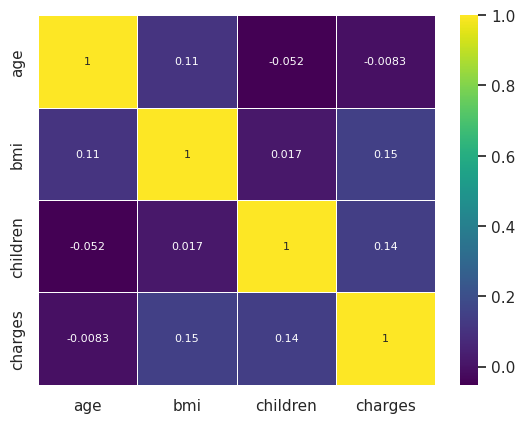

In [4]:
sns.set_theme(style="whitegrid")
sns.heatmap(data=df_corr, annot=True, linewidths=0.5, annot_kws={"size": 8},cmap='viridis')
plt.show()

It is worth removing the upper part in correlation heatmaps since it is repeated information.

* We create a mask to hide the upper part. We do that in the first two lines of code, where we create an array of zeros and set as true the upper diagonal. The upper diagonal will be hidden when you parse ``mask=mask`` at ``sns.heatmap()`` We will study them in more details correlation in upcoming lessons

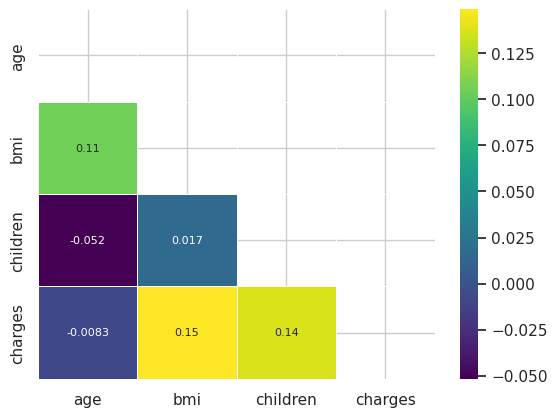

In [5]:
mask = np.zeros_like(df_corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_corr,annot=True,mask=mask,cmap='viridis',annot_kws={"size": 8},linewidths=0.5)
plt.ylim(df_corr.shape[1],0);
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE** We will use the DataFrame below, which uses the Features dataset. It contains data related to the store and regional activity for the given dates.
* Let's consider the 1st store only and drop columns related to holiday markdowns

In [6]:
df_practice = pd.read_csv('Features_data_set.csv')
df_practice.query('Store==1',inplace=True)
df_practice = df_practice[['Date','Temperature','Fuel_Price','CPI','Unemployment']]
df_practice.head()

,Date,Temperature,Fuel_Price,CPI,Unemployment
0,05/02/2010,42.31,2.572,211.096358,8.106
1,12/02/2010,38.51,2.548,211.242170,8.106
2,19/02/2010,39.93,2.514,211.289143,8.106
3,26/02/2010,46.63,2.561,211.319643,8.106
4,05/03/2010,46.50,2.625,211.350143,8.106


Feel free to try out your ideas or use the following suggestion.

Create a heatmap from the ``Features`` dataset, calculating the correlation levels using pearson and removing the upper part since it is repeated information.

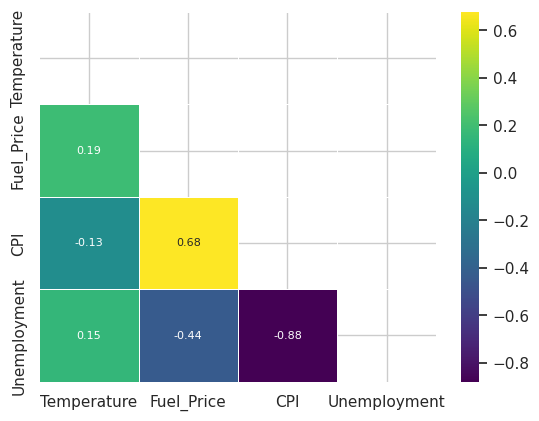

In [7]:
# Write your code here.
df_corr = df_practice.corr(method='pearson', numeric_only=True)
mask = np.zeros_like(df_corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(data=df_corr, annot=True, mask=mask, linewidths=0.5, annot_kws={"size": 8},cmap='viridis')
plt.ylim(df_corr.shape[1],0);
plt.show()

---

Let's now consider Uk MacroData dataset
* It shows GDP, CPI, Bank Rate and Investment records from 2000 to 2023. 

In [8]:
df = pd.read_csv("UK_MacroData.csv")
df['year'] = df['Date'].str[:4]
df['quarter'] = df['Date'].str[-2:]
df.head()

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments),year,quarter
0,2000 Q1,401242,1.1,5.875,69114.0,2000,Q1
1,2000 Q2,404196,1.0,6.000,73074.0,2000,Q2
2,2000 Q3,406795,1.2,6.000,68011.0,2000,Q3
3,2000 Q4,409411,1.4,6.000,70115.0,2000,Q4
4,2001 Q1,413054,1.3,5.750,70186.0,2001,Q1


You can pivot the data with a Pandas function we studied already: `pd.pivot_table()`
* That generates a table where columns are related to the year and indices to the quarter. Each cell shows GDP records for a given quarter in a given year

In [9]:
df_pivot = pd.pivot_table(data=df, index='year', columns='quarter', values='GDP (£ m)')
df_pivot

quarter,Q1,Q2,Q3,Q4
year,,,,
2000,401242.0,404196.0,406795.0,409411.0
2001,413054.0,414878.0,417085.0,418445.0
2002,419534.0,421587.0,424425.0,427725.0
2003,430832.0,434837.0,438710.0,442172.0
2004,443853.0,446443.0,448171.0,450464.0
2005,453784.0,457557.0,461135.0,465451.0
2006,467840.0,469655.0,470918.0,473372.0
2007,477823.0,481314.0,484544.0,487413.0
2008,489783.0,487386.0,479872.0,469694.0


We plot a heatmap using `sns.heatmap()`
* We don't need to mask cells here since each cell represents unique information

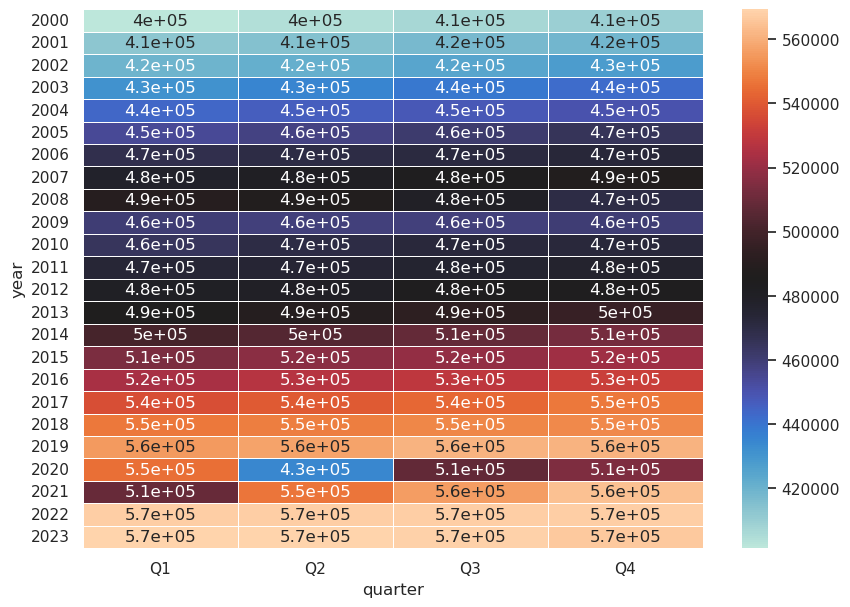

In [10]:
fig, axes = plt.subplots(figsize=(10,7))
sns.heatmap(data=df_pivot, annot=True, linewidths=.5, cmap='icefire')
plt.show()

`fmt` is a string formatting code to use when adding annotations. `fmt="0.f"` it changes the default scientific notation to "zero" decimal precision. It could be no decimal precision or one or two decimal precision. It will depend on your use case

* Can you identify the quarter where the GDP is typically higher? You may say in the Q4 of the year.
* Can you notice that the levels have increased over the years?
* Can you show the Covid19 pandemic periods on the heatmap?

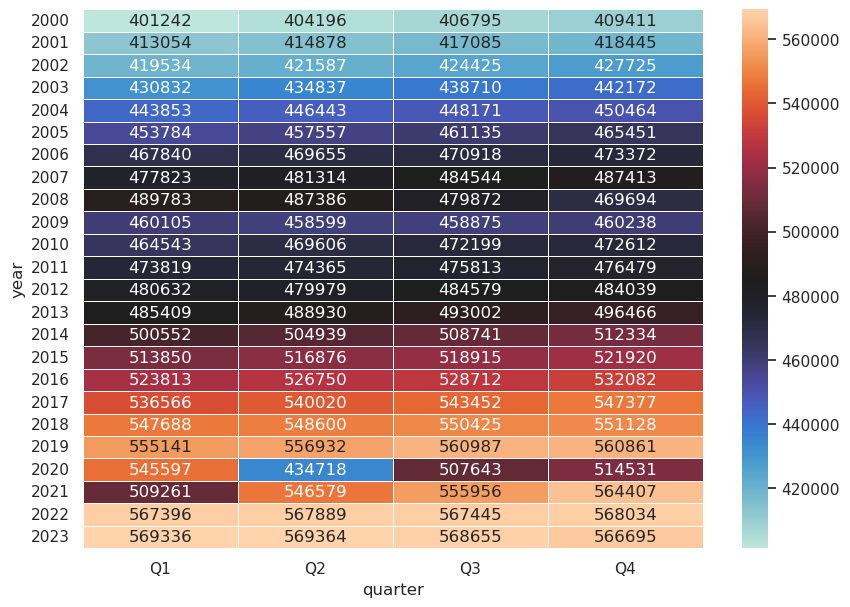

In [11]:
fig, axes = plt.subplots(figsize=(10,7))
sns.heatmap(data=df_pivot, annot=True, fmt=".0f", linewidths=.5, cmap='icefire')
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Line Plot

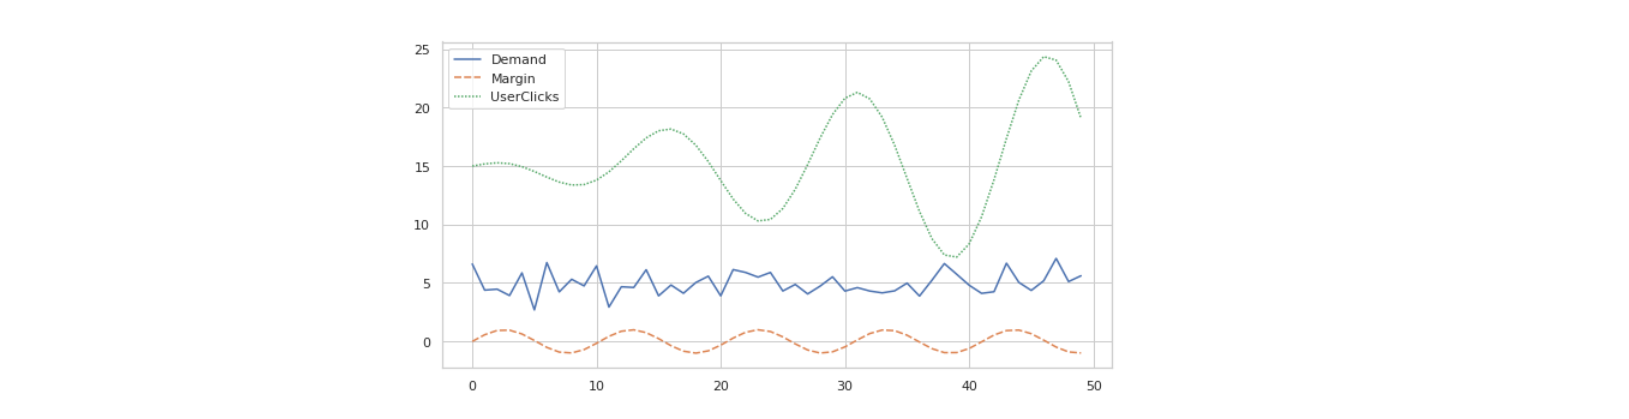

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

A line plot displays information as a series of data points in a two-dimensional chart - x and y-axis. Line plots are fundamental for visualising data trends over time (time series) or ordered categories. They can be used to track changes over intervals, highlighting trends, growth, or cycles in the data.

* **When to Use:** Ideal for any time series analysis, or when data needs to be displayed as a continuous curve to show trends. This is perhaps the most direct method for observing how variables evolve over time or through a sequence.
* **Example Application:** Frequently used in economic data analysis like tracking stock prices, GDP growth over years, or in science to plot changes in temperature, population growth, or similar metrics over time.
* It allows you to see the relationship between variables

Let's generate some data with NumPy; there are three columns created with mathematical functions
* For the purpose of the exercise, let's imagine they are a business metric, like Demand, Margin, and user clicks

In [12]:
np.random.seed(seed=1)
x= np.linspace(start=0,stop=10,num=50)
df = pd.DataFrame(data={"Demand":np.random.randn(50) + 5,
                        "Margin":np.sin(3*x),
                        "UserClicks":15 + np.cos(2*x) * x,
})

df.head(3)

,Demand,Margin,UserClicks
0,6.624345,0.000000,15.000000
1,4.388244,0.574706,15.187317
2,4.471828,0.940633,15.279552


We use `sns.lineplot()`, the documentation is [here](https://seaborn.pydata.org/generated/seaborn.lineplot.html). When you  parse the dataset, it plots a line plot for each numerical variable in the y axis and the x axis is the index
* Alternatively, you can manually set the y and x. In our case, we just parsed the data

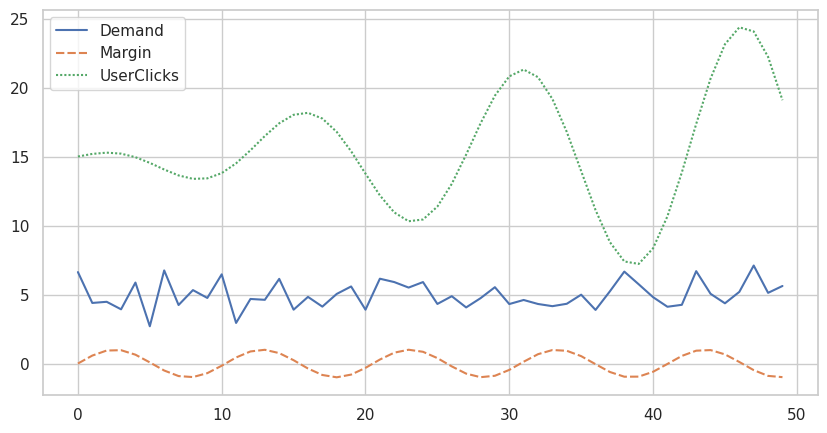

In [13]:
fig, axes = plt.subplots(figsize=(10,5))
sns.lineplot(data=df)
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Categorical Plot

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

According to Seaborn [documentation](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot), a Count Plot shows the counts of observations in each categorical bin using bars. A count plot can be considered a histogram across a categorical instead of a quantitative variable. `catplot` is for drawing categorical plots onto a figure, making it easy to separate plots by categorical classes. It can create various kinds of plots, including bar plots, box plots, violin plots, and point plots.

* **When to Use:** This is used when you need to compare data across categorical variables and want to see the distribution of a variable or compare several groups. It’s extremely useful for analyses where categorical data segmentation is critical.
* **Example Application:** Useful in market research for comparing customer satisfaction ratings across products or demographic groups, in medicine for comparing drug efficacy across different patient groups, or in surveys to visualise responses across multiple choice questions.

Consider the insurance dataset
  * It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges

In [14]:
df = pd.read_csv('insurance.csv')
df = df.sample(n=200, random_state=1)
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


We use `sns.countplot()` to generate a count plot; the documentation is [here](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot). The arguments we pass are:
* data as the DataFrane, and x for the categorical variable we want to know plot the count

/tmp/ipykernel_180205/2196421964.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="region", palette='deep')


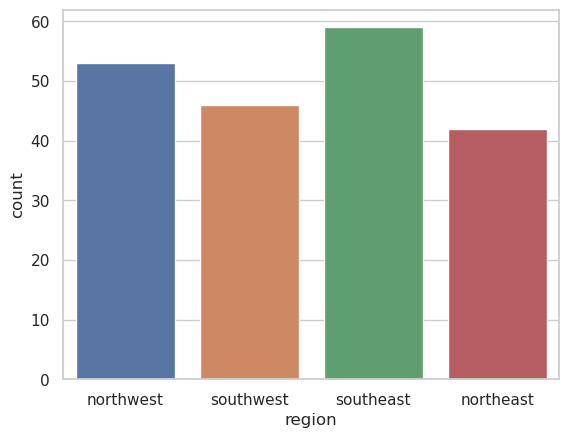

In [16]:
sns.countplot(data=df, x="region", palette='deep')
plt.show()

You can add a ``hue`` parameter, which will be a categorical variable too. In that way, you can see the frequencies of a given variable on another variable
* You will notice the bars are not stacked; they are side by side

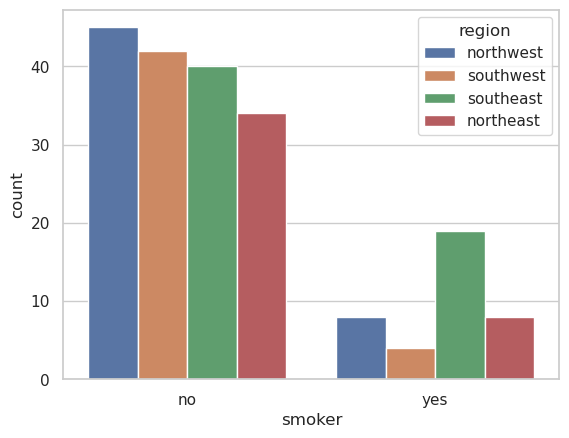

In [17]:
sns.countplot(data=df, x="smoker", hue='region')
plt.show()

The function `sns.countplot()` does not offer a stacked bar plot. To have the same effect as a stacked bar plot, you can use `sns.distplot() `

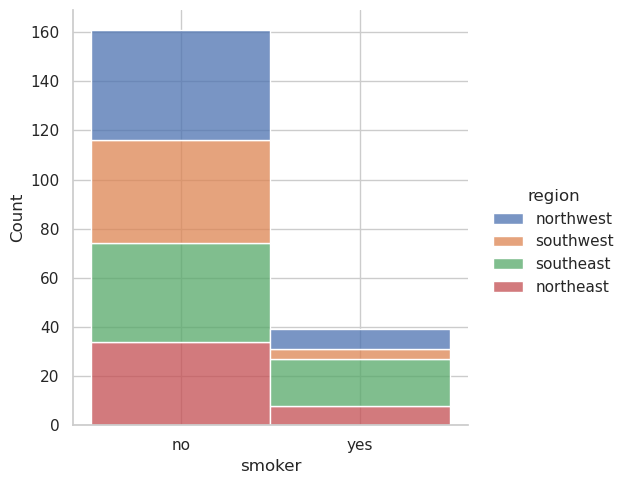

In [18]:
sns.displot(df, x='smoker', hue='region', multiple='stack')
plt.show()

Alternatively, you can consider Pandas' built-in plotting capabilities. The central aspect is that you have options when you want to deliver a stacked bar plot

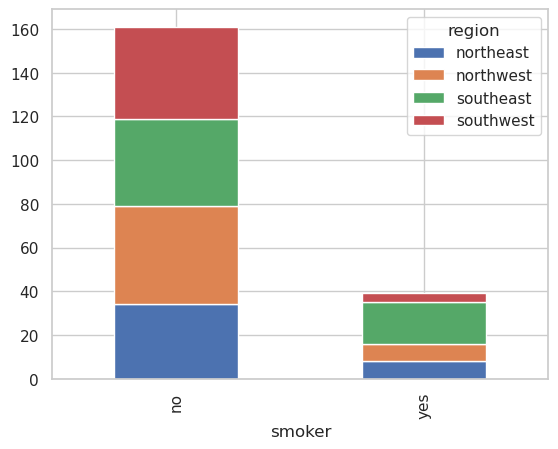

In [19]:
df.groupby(['smoker','region']).size().unstack().plot(kind='bar', stacked=True)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE** Feel free to try out your ideas or use the following suggestion.

Using the tips dataset, create a Categorical plot that should display the count of the number of Dinners and Lunches for each of the Days

In [20]:
df_practice = sns.load_dataset('tips')
df_practice = df_practice.sample(n=50, random_state=1)
df_practice.head(3)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
243,18.78,3.00,Female,No,Thur,Dinner,2
206,26.59,3.41,Male,Yes,Sat,Dinner,3


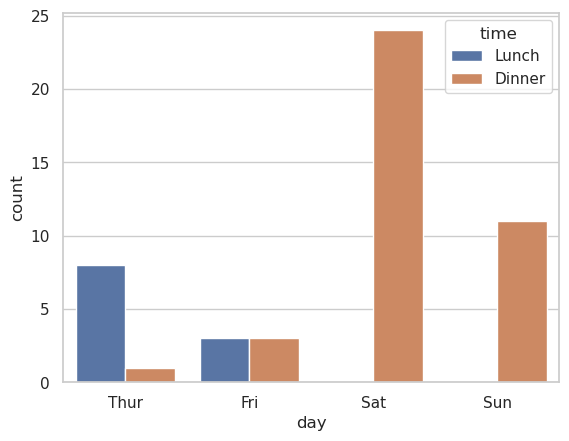

In [25]:
# Write your code here.
sns.countplot(data=df_practice, x="day", hue='time')
plt.show()